In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(
    0,
    str(PROJECT_ROOT)
)

import json
import random
import time

import numpy as np
import matplotlib.pyplot as plt
import torch

from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env

from environment import PlatformerEnv

In [3]:
SEED = 42

TOTAL_TIMESTEPS = 20_000

MAX_EPISODE_STEPS = 1000

LEARNING_RATE = 3e-4

N_STEPS = 1024

BATCH_SIZE = 64

N_EPOCHS = 10

GAMMA = 0.99

GAE_LAMBDA = 0.95

CLIP_RANGE = 0.2

ENT_COEF = 0.01

EVALUATION_EPISODES = 100

In [4]:
random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

print("Seed:", SEED)

Seed: 42


In [5]:
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
LOGS_DIR = PROJECT_ROOT / "logs"

MODELS_DIR.mkdir(
    exist_ok=True
)

RESULTS_DIR.mkdir(
    exist_ok=True
)

LOGS_DIR.mkdir(
    exist_ok=True
)

print("Models:", MODELS_DIR)
print("Results:", RESULTS_DIR)
print("Logs:", LOGS_DIR)

Models: /Users/bammy/Documents/mario_rl/models
Results: /Users/bammy/Documents/mario_rl/results
Logs: /Users/bammy/Documents/mario_rl/logs


In [6]:
env = PlatformerEnv(
    max_steps=MAX_EPISODE_STEPS
)

check_env(
    env,
    warn=True
)

print("Environment passed check_env().")

env.close()

Environment passed check_env().


In [7]:
env = PlatformerEnv(
    max_steps=MAX_EPISODE_STEPS
)

observation, info = env.reset(
    seed=SEED
)

print("Observation:")
print(observation)

print("\nObservation shape:")
print(observation.shape)

print("\nInfo:")
print(info)

env.close()

Observation:
[0.05       0.75       0.         0.         0.         0.55
 0.86333334 0.76       0.86333334 0.94       0.75      ]

Observation shape:
(11,)

Info:
{'player_x': 50, 'player_y': 450, 'goal_x': 940, 'distance_to_goal': 890, 'won': False, 'steps': 0}


In [8]:
def evaluate_agent(
    env,
    model=None,
    episodes=100,
    seed=42,
    random_policy=False,
):

    episode_rewards = []

    episode_lengths = []

    furthest_positions = []

    successes = []

    rng = np.random.default_rng(seed)

    for episode in range(episodes):

        episode_seed = seed + episode

        observation, info = env.reset(
            seed=episode_seed
        )

        total_reward = 0.0

        steps = 0

        furthest_x = info["player_x"]

        terminated = False
        truncated = False

        while not terminated and not truncated:

            if random_policy:

                action = int(
                    rng.integers(
                        env.action_space.n
                    )
                )

            else:

                action, _ = model.predict(
                    observation,
                    deterministic=True,
                )

                action = int(action)

            (
                observation,
                reward,
                terminated,
                truncated,
                info,
            ) = env.step(action)

            total_reward += reward

            steps += 1

            furthest_x = max(
                furthest_x,
                info["player_x"],
            )

        episode_rewards.append(
            total_reward
        )

        episode_lengths.append(
            steps
        )

        furthest_positions.append(
            furthest_x
        )

        successes.append(
            1 if info["won"] else 0
        )

    results = {
        "mean_reward": float(
            np.mean(episode_rewards)
        ),

        "std_reward": float(
            np.std(episode_rewards)
        ),

        "success_rate": float(
            np.mean(successes)
        ),

        "mean_furthest_x": float(
            np.mean(furthest_positions)
        ),

        "mean_episode_length": float(
            np.mean(episode_lengths)
        ),
    }

    return results

In [9]:
random_env = PlatformerEnv(
    max_steps=MAX_EPISODE_STEPS
)

random_results = evaluate_agent(
    env=random_env,
    episodes=100,
    seed=SEED,
    random_policy=True,
)

random_env.close()

print("RANDOM AGENT")
print("------------")

print(
    "Mean reward:",
    round(
        random_results["mean_reward"],
        3
    )
)

print(
    "Success rate:",
    f"{random_results['success_rate'] * 100:.1f}%"
)

print(
    "Mean furthest X:",
    round(
        random_results[
            "mean_furthest_x"
        ],
        1
    )
)

print(
    "Mean episode length:",
    round(
        random_results[
            "mean_episode_length"
        ],
        1
    )
)

RANDOM AGENT
------------
Mean reward: -5.838
Success rate: 0.0%
Mean furthest X: 131.8
Mean episode length: 697.1


In [10]:
train_env = PlatformerEnv(
    max_steps=MAX_EPISODE_STEPS
)

observation, info = train_env.reset(
    seed=SEED
)

print("Training environment ready.")

print("Starting observation:")
print(observation)

Training environment ready.
Starting observation:
[0.05       0.75       0.         0.         0.         0.55
 0.86333334 0.76       0.86333334 0.94       0.75      ]


In [11]:
model = PPO(
    policy="MlpPolicy",

    env=train_env,

    learning_rate=LEARNING_RATE,

    n_steps=N_STEPS,

    batch_size=BATCH_SIZE,

    n_epochs=N_EPOCHS,

    gamma=GAMMA,

    gae_lambda=GAE_LAMBDA,

    clip_range=CLIP_RANGE,

    ent_coef=ENT_COEF,

    seed=SEED,

    verbose=1,

    tensorboard_log=str(
        LOGS_DIR
    ),
)

print("PPO model created.")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
PPO model created.


In [12]:
%pip install tqdm rich

Note: you may need to restart the kernel to use updated packages.


In [13]:
untrained_env = PlatformerEnv(
    max_steps=MAX_EPISODE_STEPS
)

untrained_results = evaluate_agent(
    env=untrained_env,
    model=model,
    episodes=20,
    seed=SEED,
)

untrained_env.close()

print("UNTRAINED PPO")
print("-------------")

print(
    "Mean reward:",
    round(
        untrained_results["mean_reward"],
        3
    )
)

print(
    "Success rate:",
    f"{untrained_results['success_rate'] * 100:.1f}%"
)

print(
    "Mean furthest X:",
    round(
        untrained_results["mean_furthest_x"],
        1
    )
)

print(
    "Mean episode length:",
    round(
        untrained_results["mean_episode_length"],
        1
    )
)

UNTRAINED PPO
-------------
Mean reward: -11.6
Success rate: 0.0%
Mean furthest X: 50.0
Mean episode length: 32.0


In [14]:
model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    progress_bar=True,
)

Logging to /Users/bammy/Documents/mario_rl/logs/PPO_5


/Users/bammy/Documents/mario_rl/.venv/lib/python3.13/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | 1.83     |
| time/              |          |
|    fps             | 10303    |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 1024     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 573         |
|    ep_rew_mean          | -4.18       |
| time/                   |             |
|    fps                  | 7182        |
|    iterations           | 2           |
|    time_elapsed         | 0           |
|    total_timesteps      | 2048        |
| train/                  |             |
|    approx_kl            | 0.022457141 |
|    clip_fraction        | 0.34        |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.78       |
|    explained_variance   | -1.5        |
|    learning_rate        | 0.

In [15]:
SMOKE_MODEL_PATH = (
    MODELS_DIR / "ppo_smoke_20k"
)

model.save(
    str(SMOKE_MODEL_PATH)
)

print(
    "Smoke-test model saved to:",
    str(SMOKE_MODEL_PATH) + ".zip"
)

Smoke-test model saved to: /Users/bammy/Documents/mario_rl/models/ppo_smoke_20k.zip


In [16]:
smoke_eval_env = PlatformerEnv(
    max_steps=MAX_EPISODE_STEPS
)

smoke_results = evaluate_agent(
    env=smoke_eval_env,
    model=model,
    episodes=100,
    seed=SEED,
)

smoke_eval_env.close()

print("PPO AFTER 20K TRAINING STEPS")
print("----------------------------")

print(
    "Mean reward:",
    round(
        smoke_results["mean_reward"],
        3
    )
)

print(
    "Success rate:",
    f"{smoke_results['success_rate'] * 100:.1f}%"
)

print(
    "Mean furthest X:",
    round(
        smoke_results["mean_furthest_x"],
        1
    )
)

print(
    "Mean episode length:",
    round(
        smoke_results["mean_episode_length"],
        1
    )
)

PPO AFTER 20K TRAINING STEPS
----------------------------
Mean reward: -3.17
Success rate: 0.0%
Mean furthest X: 733.0
Mean episode length: 143.0


In [17]:
import pygame
import time

play_env = PlatformerEnv(
    render_mode="human",
    max_steps=MAX_EPISODE_STEPS,
)

observation, info = play_env.reset(seed=SEED)

terminated = False
truncated = False
total_reward = 0.0

while not terminated and not truncated:

    # Keep the Pygame window responsive
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            terminated = True
            break

    if terminated:
        break

    # Ask our trained PPO agent what action to take
    action, _ = model.predict(
        observation,
        deterministic=True,
    )

    # Perform that action in the game
    observation, reward, terminated, truncated, info = play_env.step(
        int(action)
    )

    total_reward += reward

    # Slow the game down to approximately 60 FPS
    # so we can actually watch it.
    time.sleep(1 / 60)

print("Episode finished")
print("Won:", info["won"])
print("Final X:", info["player_x"])
print("Total reward:", round(total_reward, 3))
print("Steps:", info["steps"])

play_env.close()

Episode finished
Won: False
Final X: 733
Total reward: -3.17
Steps: 143


In [18]:
FINAL_TOTAL_TIMESTEPS = 204_800
EVAL_INTERVAL = 10_240

final_train_env = PlatformerEnv(
    max_steps=MAX_EPISODE_STEPS
)

final_train_env.reset(
    seed=SEED
)

final_model = PPO(
    policy="MlpPolicy",
    env=final_train_env,

    learning_rate=LEARNING_RATE,
    n_steps=N_STEPS,
    batch_size=BATCH_SIZE,
    n_epochs=N_EPOCHS,

    gamma=GAMMA,
    gae_lambda=GAE_LAMBDA,
    clip_range=CLIP_RANGE,
    ent_coef=ENT_COEF,

    seed=SEED,
    verbose=0,

    tensorboard_log=str(LOGS_DIR),
)

print("Fresh PPO model created.")
print("Current timesteps:", final_model.num_timesteps)
print("Target timesteps:", FINAL_TOTAL_TIMESTEPS)
print("Evaluation interval:", EVAL_INTERVAL)

Fresh PPO model created.
Current timesteps: 0
Target timesteps: 204800
Evaluation interval: 10240


In [19]:
timesteps_history = []
reward_history = []
success_history = []
furthest_x_history = []
episode_length_history = []

print("Learning-curve storage ready.")

Learning-curve storage ready.


In [20]:
while final_model.num_timesteps < FINAL_TOTAL_TIMESTEPS:

    # Train for another 10,240 interactions
    final_model.learn(
        total_timesteps=EVAL_INTERVAL,
        reset_num_timesteps=False,
        progress_bar=False,
    )

    actual_steps = final_model.num_timesteps

    # Create a separate environment for evaluation
    eval_env = PlatformerEnv(
        max_steps=MAX_EPISODE_STEPS
    )

    results = evaluate_agent(
        env=eval_env,
        model=final_model,
        episodes=20,
        seed=SEED,
    )

    eval_env.close()

    # Record results for our learning curves
    timesteps_history.append(
        actual_steps
    )

    reward_history.append(
        results["mean_reward"]
    )

    success_history.append(
        results["success_rate"]
    )

    furthest_x_history.append(
        results["mean_furthest_x"]
    )

    episode_length_history.append(
        results["mean_episode_length"]
    )

    print(
        f"Steps: {actual_steps:>6} | "
        f"Reward: {results['mean_reward']:>7.2f} | "
        f"Success: {results['success_rate'] * 100:>5.1f}% | "
        f"Furthest X: {results['mean_furthest_x']:>6.1f}"
    )

Steps:  10240 | Reward:    0.00 | Success:   0.0% | Furthest X:   50.0
Steps:  20480 | Reward:   -3.17 | Success:   0.0% | Furthest X:  733.0
Steps:  30720 | Reward:   18.63 | Success: 100.0% | Furthest X:  913.0
Steps:  40960 | Reward:    2.03 | Success:   0.0% | Furthest X:  273.0
Steps:  51200 | Reward:    1.73 | Success:   0.0% | Furthest X:  253.0
Steps:  61440 | Reward:    2.13 | Success:   0.0% | Furthest X:  273.0
Steps:  71680 | Reward:    2.63 | Success:   0.0% | Furthest X:  318.0
Steps:  81920 | Reward:    2.48 | Success:   0.0% | Furthest X:  303.0
Steps:  92160 | Reward:    2.83 | Success:   0.0% | Furthest X:  348.0
Steps: 102400 | Reward:    2.53 | Success:   0.0% | Furthest X:  308.0
Steps: 112640 | Reward:    2.73 | Success:   0.0% | Furthest X:  323.0
Steps: 122880 | Reward:    2.53 | Success:   0.0% | Furthest X:  308.0
Steps: 133120 | Reward:    2.73 | Success:   0.0% | Furthest X:  323.0
Steps: 143360 | Reward:    2.63 | Success:   0.0% | Furthest X:  323.0
Steps:

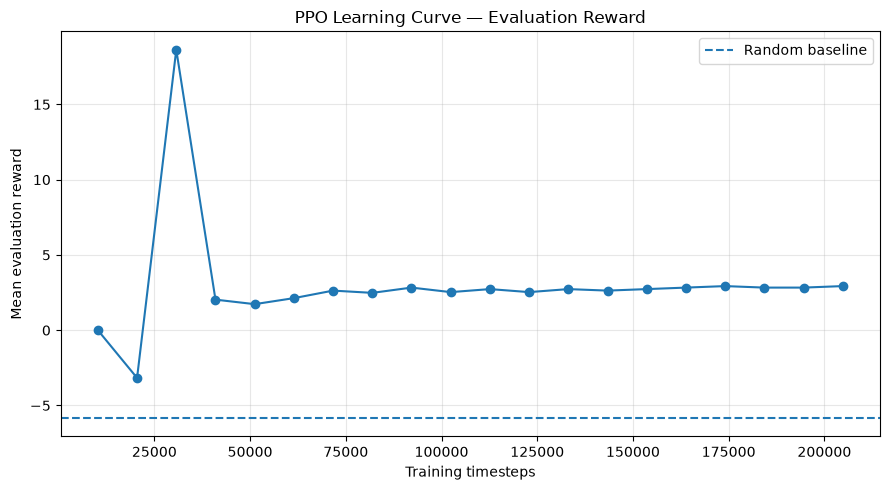

In [21]:
plt.figure(figsize=(9, 5))

plt.plot(
    timesteps_history,
    reward_history,
    marker="o",
)

plt.axhline(
    y=random_results["mean_reward"],
    linestyle="--",
    label="Random baseline",
)

plt.xlabel("Training timesteps")
plt.ylabel("Mean evaluation reward")
plt.title("PPO Learning Curve — Evaluation Reward")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "reward_curve.png"
)

plt.show()

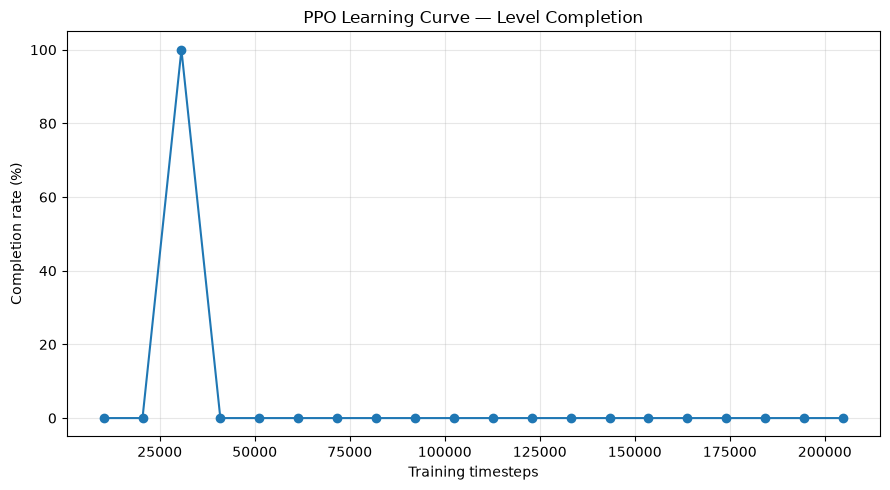

In [22]:
success_percent = [
    rate * 100
    for rate in success_history
]

plt.figure(figsize=(9, 5))

plt.plot(
    timesteps_history,
    success_percent,
    marker="o",
)

plt.xlabel("Training timesteps")
plt.ylabel("Completion rate (%)")
plt.title("PPO Learning Curve — Level Completion")

plt.ylim(-5, 105)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "completion_curve.png"
)

plt.show()

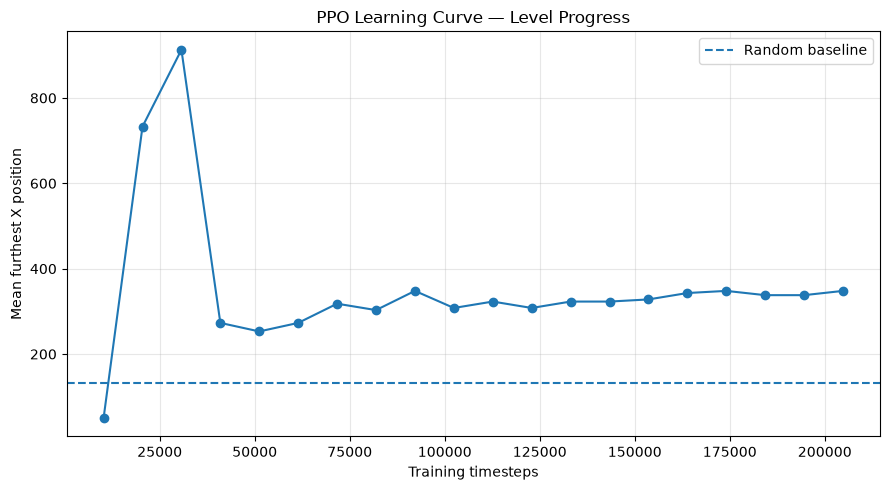

In [23]:
plt.figure(figsize=(9, 5))

plt.plot(
    timesteps_history,
    furthest_x_history,
    marker="o",
)

plt.axhline(
    y=random_results["mean_furthest_x"],
    linestyle="--",
    label="Random baseline",
)

plt.xlabel("Training timesteps")
plt.ylabel("Mean furthest X position")
plt.title("PPO Learning Curve — Level Progress")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "progress_curve.png"
)

plt.show()

In [24]:
learning_curve_data = []

for i in range(len(timesteps_history)):
    learning_curve_data.append({
        "timesteps": timesteps_history[i],
        "mean_reward": reward_history[i],
        "success_rate": success_history[i],
        "mean_furthest_x": furthest_x_history[i],
        "mean_episode_length": episode_length_history[i],
    })

with open(
    RESULTS_DIR / "learning_curve.json",
    "w",
) as file:
    json.dump(
        learning_curve_data,
        file,
        indent=4,
    )

print("Learning-curve data saved.")

Learning-curve data saved.


In [25]:
BEST_MODEL_PATH = MODELS_DIR / "ppo_platformer_best"

best_success_rate = -1.0
best_mean_reward = float("-inf")
best_timesteps = 0

print("Best-model tracking initialized.")

Best-model tracking initialized.


In [26]:
best_train_env = PlatformerEnv(
    max_steps=MAX_EPISODE_STEPS
)

best_train_env.reset(seed=SEED)

best_model = PPO(
    policy="MlpPolicy",
    env=best_train_env,

    learning_rate=LEARNING_RATE,
    n_steps=N_STEPS,
    batch_size=BATCH_SIZE,
    n_epochs=N_EPOCHS,

    gamma=GAMMA,
    gae_lambda=GAE_LAMBDA,
    clip_range=CLIP_RANGE,
    ent_coef=ENT_COEF,

    seed=SEED,
    verbose=0,

    tensorboard_log=str(LOGS_DIR),
)

print("Fresh best-checkpoint experiment created.")
print("Starting timesteps:", best_model.num_timesteps)

Fresh best-checkpoint experiment created.
Starting timesteps: 0


In [27]:
while best_model.num_timesteps < FINAL_TOTAL_TIMESTEPS:

    best_model.learn(
        total_timesteps=EVAL_INTERVAL,
        reset_num_timesteps=False,
        progress_bar=False,
    )

    actual_steps = best_model.num_timesteps

    eval_env = PlatformerEnv(
        max_steps=MAX_EPISODE_STEPS
    )

    results = evaluate_agent(
        env=eval_env,
        model=best_model,
        episodes=20,
        seed=SEED,
    )

    eval_env.close()

    success = results["success_rate"]
    reward = results["mean_reward"]

    is_better = (
        success > best_success_rate
        or (
            success == best_success_rate
            and reward > best_mean_reward
        )
    )

    if is_better:
        best_success_rate = success
        best_mean_reward = reward
        best_timesteps = actual_steps

        best_model.save(
            str(BEST_MODEL_PATH)
        )

        marker = " <-- SAVED BEST"
    else:
        marker = ""

    print(
        f"Steps: {actual_steps:>6} | "
        f"Reward: {reward:>7.2f} | "
        f"Success: {success * 100:>5.1f}% | "
        f"Furthest X: {results['mean_furthest_x']:>6.1f}"
        f"{marker}"
    )

Steps:  10240 | Reward:    0.00 | Success:   0.0% | Furthest X:   50.0 <-- SAVED BEST
Steps:  20480 | Reward:   -3.17 | Success:   0.0% | Furthest X:  733.0
Steps:  30720 | Reward:   18.63 | Success: 100.0% | Furthest X:  913.0 <-- SAVED BEST
Steps:  40960 | Reward:    2.03 | Success:   0.0% | Furthest X:  273.0
Steps:  51200 | Reward:    1.73 | Success:   0.0% | Furthest X:  253.0
Steps:  61440 | Reward:    2.13 | Success:   0.0% | Furthest X:  273.0
Steps:  71680 | Reward:    2.63 | Success:   0.0% | Furthest X:  318.0
Steps:  81920 | Reward:    2.48 | Success:   0.0% | Furthest X:  303.0
Steps:  92160 | Reward:    2.83 | Success:   0.0% | Furthest X:  348.0
Steps: 102400 | Reward:    2.53 | Success:   0.0% | Furthest X:  308.0
Steps: 112640 | Reward:    2.73 | Success:   0.0% | Furthest X:  323.0
Steps: 122880 | Reward:    2.53 | Success:   0.0% | Furthest X:  308.0
Steps: 133120 | Reward:    2.73 | Success:   0.0% | Furthest X:  323.0
Steps: 143360 | Reward:    2.63 | Success:   0.

In [28]:
loaded_best_model = PPO.load(
    str(BEST_MODEL_PATH)
)

print("Best model loaded successfully.")
print("Saved checkpoint timesteps:", best_timesteps)
print("Saved checkpoint success:", f"{best_success_rate * 100:.1f}%")
print("Saved checkpoint reward:", round(best_mean_reward, 2))

Best model loaded successfully.
Saved checkpoint timesteps: 30720
Saved checkpoint success: 100.0%
Saved checkpoint reward: 18.63


In [29]:
final_eval_env = PlatformerEnv(
    max_steps=MAX_EPISODE_STEPS
)

ppo_results = evaluate_agent(
    env=final_eval_env,
    model=loaded_best_model,
    episodes=100,
    seed=SEED,
)

final_eval_env.close()

print("FINAL SAVED PPO")
print("---------------")

print(
    "Mean reward:",
    round(ppo_results["mean_reward"], 3)
)

print(
    "Success rate:",
    f"{ppo_results['success_rate'] * 100:.1f}%"
)

print(
    "Mean furthest X:",
    round(ppo_results["mean_furthest_x"], 1)
)

print(
    "Mean episode length:",
    round(ppo_results["mean_episode_length"], 1)
)

FINAL SAVED PPO
---------------
Mean reward: 18.63
Success rate: 100.0%
Mean furthest X: 913.0
Mean episode length: 187.0


In [30]:
print(
    f"{'Metric':<25}"
    f"{'Random':>15}"
    f"{'PPO':>15}"
)

print("-" * 55)

print(
    f"{'Mean reward':<25}"
    f"{random_results['mean_reward']:>15.2f}"
    f"{ppo_results['mean_reward']:>15.2f}"
)

print(
    f"{'Success rate':<25}"
    f"{random_results['success_rate'] * 100:>14.1f}%"
    f"{ppo_results['success_rate'] * 100:>14.1f}%"
)

print(
    f"{'Mean furthest X':<25}"
    f"{random_results['mean_furthest_x']:>15.1f}"
    f"{ppo_results['mean_furthest_x']:>15.1f}"
)

print(
    f"{'Episode length':<25}"
    f"{random_results['mean_episode_length']:>15.1f}"
    f"{ppo_results['mean_episode_length']:>15.1f}"
)

Metric                            Random            PPO
-------------------------------------------------------
Mean reward                        -5.84          18.63
Success rate                        0.0%         100.0%
Mean furthest X                    131.8          913.0
Episode length                     697.1          187.0


In [31]:
comparison = {
    "random": random_results,
    "ppo": ppo_results,
    "ppo_checkpoint_timesteps": best_timesteps,
}

with open(
    RESULTS_DIR / "comparison.json",
    "w",
) as file:
    json.dump(
        comparison,
        file,
        indent=4,
    )

print("Comparison saved.")

Comparison saved.


In [35]:
import pygame
import time

play_env = PlatformerEnv(
    render_mode="human",
    max_steps=MAX_EPISODE_STEPS,
)

observation, info = play_env.reset(
    seed=SEED
)

terminated = False
truncated = False
total_reward = 0.0

while not terminated and not truncated:

    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            terminated = True
            break

    if terminated:
        break

    action, _ = loaded_best_model.predict(
        observation,
        deterministic=True,
    )

    observation, reward, terminated, truncated, info = (
        play_env.step(int(action))
    )

    total_reward += reward

    time.sleep(1 / 60)

print("Episode finished")
print("Won:", info["won"])
print("Final X:", info["player_x"])
print("Total reward:", round(total_reward, 3))
print("Steps:", info["steps"])

play_env.close()

Episode finished
Won: True
Final X: 913
Total reward: 18.63
Steps: 187


In [33]:
headline_results = {
    "seed": SEED,
    "training_budget": FINAL_TOTAL_TIMESTEPS,
    "best_checkpoint_timesteps": best_timesteps,
    "random_baseline": random_results,
    "best_ppo": ppo_results,
    "selection_rule": (
        "Highest evaluation success rate; "
        "mean reward used as tie-breaker."
    ),
    "evaluation_note": (
        "Environment and evaluation policy are deterministic. "
        "Repeated evaluation episodes therefore reproduce the "
        "same trajectory for a fixed checkpoint."
    ),
}

with open(
    RESULTS_DIR / "headline_results.json",
    "w",
) as file:
    json.dump(
        headline_results,
        file,
        indent=4,
    )

print("Headline results saved.")

Headline results saved.
